### Preferential integration over Rossby wave mode
We start with the equation for the thickness anomaly at a longitude, latitude pair $(\lambda, \phi)$ due only to upwelling along Rossby waves:
$$
h = \frac{R\cos(\phi)}{c}\int_{\lambda_e}^{\lambda}w_{Ek}(\lambda',\phi,t-R\cos(\phi)(\lambda'-\lambda)/c)\,d\lambda'
$$
Next, decompose $w_{Ek}$ into Fourier modes in longitude and time:
$$
w_{Ek}(\lambda, \phi, t) = \sum_m w_m(\phi, t) e^{im\lambda} = \sum_{m}\int \frac{d\omega}{2\pi} \tilde{w}_m(\phi,\omega)e^{i(\omega t + m\lambda)}
$$
The physical wavenumber associated with the integer wavenumber $m$ is $k_m = \frac{m}{R\cos(\phi)}$. We substitute this decomposition into the expression for $h$ to obtain, after swapping order of integration:
$$
h = \frac{R\cos(\phi)}{c}\sum_m \int \frac{d\omega}{2\pi} \int_{\lambda_e}^\lambda d\lambda' \tilde{w}_m(\phi, \omega)e^{i(\omega (t-R\cos(\phi)\lambda'/c+R\cos(\phi)\lambda/c) + m\lambda')} = \frac{R\cos(\phi)}{c}\sum_m \int \frac{d\omega}{2\pi} \int_{\lambda_e}^\lambda d\lambda' \tilde{w}_m(\phi, \omega)e^{i\omega (t+R\cos(\phi)\lambda/c)}e^{i(m - \omega R \cos(\phi)/c)\lambda'}
$$
The integral over $\lambda'$ can be solved, introducing $\mu = m - \omega R \cos(\phi)/c$ and $\Delta\lambda = \lambda_e - \lambda > 0$:
$$
\int_{\lambda_e}^\lambda d\lambda' e^{i\mu\lambda'} = -\Delta\lambda e^{i\mu(\lambda + \lambda_e)/2}\operatorname{sinc}(\mu\Delta\lambda/2)
$$
which gives
$$
h = -\frac{R\cos(\phi)\Delta\lambda}{c}\sum_m \int \frac{d\omega}{2\pi}\tilde{w}_m(\phi, \omega)e^{i(\omega t + m\lambda)}e^{i\mu\Delta\lambda/2}\operatorname{sinc}(\mu\Delta\lambda/2).
$$

At a given latitude, the $\operatorname{sinc}$ function leads to preferential integration over components of the wind field where $\mu \approx 0 \implies \omega / k_m \approx c$. Physically, this clearly corresponds to a component of the upwelling field moving with a Rossby wave, thus allowing said wave to extract the maximum thickness anomaly possible. Away from this resonance condition, $\tilde{w}_m(\phi, \omega)$ is suppressed by a factor that falls off as $(\mu\Delta\lambda)^{-1}$.

The magnitude of the total prefactor on the $\tilde{w}_m$ term is:
$$
\Bigg|\frac{R\cos(\phi)\Delta\lambda}{c}\operatorname{sinc}(\mu\Delta\lambda/2)\Bigg|
$$
Thus the height of the resonant ridge is set by $\Delta\lambda$, and the width is set by $\Delta\lambda^{-1}$. Consider the situation south of Africa. Here, $\Delta\lambda$ rapidly grows, leading to a much narrower but higher peak in the prefactor along the resonant ridge. Nevertheless, their product (i.e. the total impact of a homogeneous wind field) remains constant. I suspect this is responsible for the change in the relationship between $w_{Ek}$ and $h_b$ variability, but I can't piece it all together just yet.

#### Implications for $T_g$
The anomaly at the outside of the WBC region is:
$$
h_b = -\frac{L}{c}\sum_m \int \frac{d\omega}{2\pi}\tilde{w}_m(\phi, \omega)e^{i(\omega t + m\lambda_b)}e^{i\mu(\lambda_e-\lambda_b)/2}\operatorname{sinc}(\mu(\lambda_e-\lambda_b)/2).
$$
Ignoring feedback effects, this leads to a geostrophic transport anomaly through:
$$
\frac{\partial T_g}{\partial \phi} = Rch_b = -R^2\cos(\phi)\Delta\lambda\sum_m \int \frac{d\omega}{2\pi}\tilde{w}_m(\phi, \omega)e^{i(\omega t + m\lambda_b)}e^{i\mu(\lambda_e-\lambda_b)/2}\operatorname{sinc}(\mu(\lambda_e-\lambda_b)/2).
$$

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
from moc_adjustment_theory.global_rossby import EARTH_RADIUS_M, EARTH_ROTATION_S, rossby_speed

winds = xr.open_dataset("/Users/awatford/Documents/GitHub/MOCAdjustmentTheory/data/untracked/ERA5/global_winds.nc").rename(valid_time="time")

def ekman_spectrum_at_latitude(winds, latitude, lon_coarsen=4, rho_0=1027.0):
    """Return the complex (omega, k) spectrum of Ekman upwelling at one latitude."""
    j = np.argmin(abs(winds.latitude.values - latitude))
    strip = winds[["avg_iews", "avg_inss"]].isel(latitude=slice(j - 1, j + 2))
    strip = strip.coarsen(longitude=lon_coarsen, boundary="trim").mean().load()
    phi = np.deg2rad(strip.latitude)
    f = 2 * EARTH_ROTATION_S * np.sin(phi)  # deliberately unregularized
    M_x, M_y = strip.avg_inss / (rho_0 * f), -strip.avg_iews / (rho_0 * f)
    dlambda = np.deg2rad(float(strip.longitude.diff("longitude").mean()))
    dM_x = (M_x.roll(longitude=-1, roll_coords=False) - M_x.roll(longitude=1, roll_coords=False)) / (2 * dlambda)
    dM_y = (M_y * np.cos(phi)).differentiate("latitude") / np.deg2rad(1)
    w = ((dM_x + dM_y) / (EARTH_RADIUS_M * np.cos(phi))).isel(latitude=1)
    w = w - w.mean("time")
    spectrum = np.fft.fftshift(np.fft.fft(np.fft.rfft(w.values, axis=0), axis=1), axes=1) / w.size
    omega = 2 * np.pi * np.fft.rfftfreq(w.sizes["time"], d=1 / 12)
    m = np.fft.fftshift(np.fft.fftfreq(w.sizes["longitude"], d=1 / w.sizes["longitude"])).astype(int)
    k = m / (EARTH_RADIUS_M * np.cos(strip.latitude[1].item() * np.pi / 180))
    return xr.DataArray(spectrum, dims=("omega", "k"), coords={"omega": omega, "k": k},
                        name="w_Ek_hat", attrs={"latitude": strip.latitude[1].item(), "units": "m s-1"})

YEAR_SECONDS = 365.25 * 24 * 3600

def basin_transfer_function(w_hat, geometry, g_prime=0.02):
    """Return (L/c) sinc[(k - omega/c)L/2] on the spectrum grid."""
    latitude = w_hat.attrs["latitude"]
    edge = geometry.sel(latitude=latitude, method="nearest")
    # Use the next eastern boundary as basins merge south of Africa/Australia.
    x_e = next(x for name in ("x_eA", "x_eI", "x_eP") if np.isfinite(x := edge[name].item()))
    L = EARTH_RADIUS_M * np.cos(np.deg2rad(latitude)) * np.deg2rad(x_e - edge.x_wA.item())
    c = rossby_speed(np.array([latitude]), g_prime, geometry.attrs["isobath_depth_m"])[0]
    detuning = w_hat.k - w_hat.omega / (YEAR_SECONDS * c)
    transfer = ((L / c) * xr.apply_ufunc(np.sinc, detuning * L / (2 * np.pi))).transpose("omega", "k")
    transfer = transfer.rename("basin_transfer_function")
    transfer.attrs.update(latitude=latitude, basin_width_m=L, rossby_speed_m_s=c, units="s")
    return transfer

In [2]:
geometry = xr.open_dataset("/Users/awatford/Documents/GitHub/MOCAdjustmentTheory/data/tracked/isobath/global_isobath_GEBCO_1000m.nc")
latitudes = [-35.0, -36.0, -37.0, -38.0, -39.0, -40.0]
rows, widths, speeds = [[], [], []], [], []
for latitude in latitudes:
    w_hat = ekman_spectrum_at_latitude(winds, latitude)
    transfer = basin_transfer_function(w_hat, geometry)
    fields = [abs(w_hat), abs(transfer), abs(w_hat * transfer)]
    for row, field in zip(rows, fields):
        field = field.sel(k=slice(-1e-5, 1e-5), omega=slice(0, 8 * np.pi))
        row.append(np.log10(field.where(field > 0)).assign_coords(k=1e6 * field.k))
    widths.append(transfer.attrs["basin_width_m"])
    speeds.append(transfer.attrs["rossby_speed_m_s"])

levels = []
for row in rows:
    values = np.concatenate([field.values[np.isfinite(field.values)] for field in row])
    levels.append(np.linspace(*np.percentile(values, [1, 99]), 31))

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


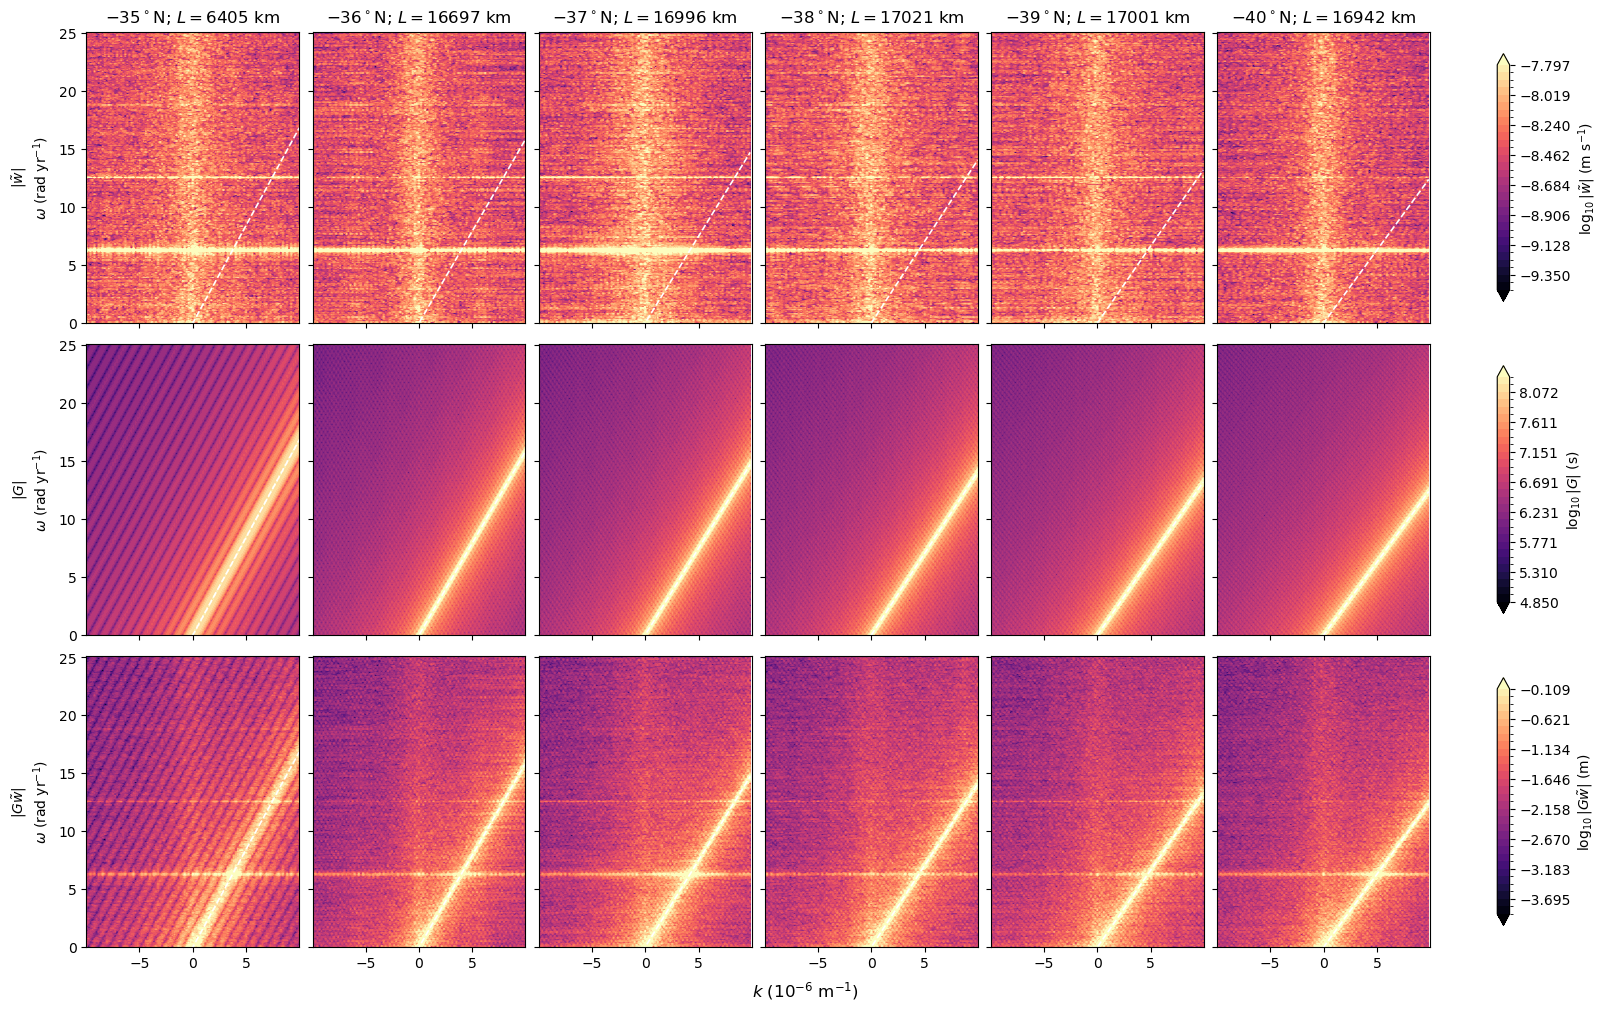

In [3]:
fig, axes = plt.subplots(3, len(latitudes), figsize=(16, 10), sharex=True, sharey=True, constrained_layout=True)
colorbar_labels = [r"$\log_{10}|\tilde w|$ (m s$^{-1}$)", r"$\log_{10}|G|$ (s)", r"$\log_{10}|G\tilde w|$ (m)"]
for i, row in enumerate(rows):
    for j, field in enumerate(row):
        contour = field.plot.contourf(ax=axes[i, j], x="k", y="omega", levels=levels[i], cmap="magma", add_colorbar=False)
        axes[i, j].plot(field.k, speeds[j] * field.k * 1e-6 * YEAR_SECONDS, "w--", lw=1.2)
        axes[i, j].set(xlabel="", ylabel="", ylim=(0, 8 * np.pi))
    fig.colorbar(contour, ax=axes[i, :], label=colorbar_labels[i], shrink=0.85)
for j, latitude in enumerate(latitudes):
    axes[0, j].set_title(fr"${latitude:g}^\circ$N; $L={widths[j] / 1e3:.0f}$ km")
for ax, label in zip(axes[:, 0], [r"$|\tilde w|$", r"$|G|$", r"$|G\tilde w|$"]):
    ax.set_ylabel(label + "\n" + r"$\omega$ (rad yr$^{-1}$)")
fig.supxlabel(r"$k$ ($10^{-6}$ m$^{-1}$)")
plt.show()

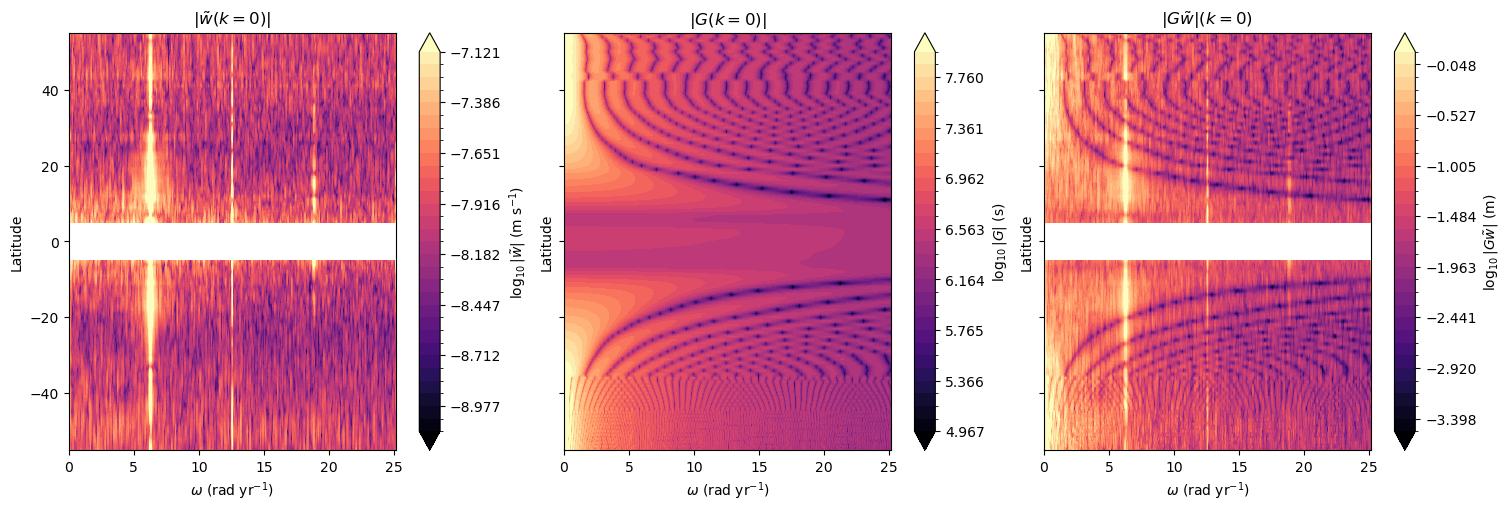

In [4]:
winds_k0 = xr.open_dataset("/Users/awatford/Documents/GitHub/MOCAdjustmentTheory/data/untracked/ERA5/global_winds.nc", chunks={})
tau_x_bar = (winds_k0.avg_iews.sel(latitude=slice(55, -55)).isel(latitude=slice(None, None, 4))
             .mean("longitude").rename(valid_time="time").compute())
phi = np.deg2rad(tau_x_bar.latitude)
f = 2 * EARTH_ROTATION_S * np.sin(phi)
M_y_bar = (-tau_x_bar / (1027.0 * f)).where(f != 0)  # no equatorial regularization
w_k0 = ((M_y_bar * np.cos(phi)).differentiate("latitude") / np.deg2rad(1)
        / (EARTH_RADIUS_M * np.cos(phi))).where(abs(tau_x_bar.latitude) >= 5)
w_k0 = (w_k0 - w_k0.mean("time")).transpose("time", "latitude")
omega = 2 * np.pi * np.fft.rfftfreq(w_k0.sizes["time"], d=1 / 12)
w_k0_hat = xr.DataArray(np.fft.rfft(w_k0.values, axis=0) / w_k0.sizes["time"],
                            dims=("omega", "latitude"), coords={"omega": omega, "latitude": w_k0.latitude})

edge = geometry.sel(latitude=xr.DataArray(w_k0.latitude.values, dims="latitude"), method="nearest").assign_coords(latitude=w_k0.latitude)
x_e = edge.x_eA.fillna(edge.x_eI).fillna(edge.x_eP)
L = EARTH_RADIUS_M * np.cos(phi) * np.deg2rad(x_e - edge.x_wA)
c = xr.DataArray(rossby_speed(w_k0.latitude.values, 0.02, geometry.attrs["isobath_depth_m"]),
                 dims="latitude", coords={"latitude": w_k0.latitude})
detuning = -w_k0_hat.omega / (YEAR_SECONDS * c)
G_k0 = ((L / c) * xr.apply_ufunc(np.sinc, detuning * L / (2 * np.pi))).transpose("omega", "latitude")

fields = [abs(w_k0_hat), abs(G_k0), abs(w_k0_hat * G_k0)]
titles = [r"$|\tilde w(k=0)|$", r"$|G(k=0)|$", r"$|G\tilde w|(k=0)$"]
cbar_labels = [r"$\log_{10}|\tilde w|$ (m s$^{-1}$)", r"$\log_{10}|G|$ (s)", r"$\log_{10}|G\tilde w|$ (m)"]
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharex=True, sharey=True, constrained_layout=True)
for ax, field, title, cbar_label in zip(axes, fields, titles, cbar_labels):
    field = np.log10(field.where(field > 0)).sel(omega=slice(0, 8 * np.pi))
    values = field.values[np.isfinite(field.values)]
    contour = field.plot.contourf(ax=ax, x="omega", y="latitude", levels=np.linspace(*np.percentile(values, [1, 99]), 31),
                                  cmap="magma", add_colorbar=False)
    fig.colorbar(contour, ax=ax, label=cbar_label)
    ax.set(title=title, xlabel=r"$\omega$ (rad yr$^{-1}$)", ylabel="Latitude")
plt.show()